## Use a pretrained VGG model for transfer learning by adding custom top layers. Incorporate dense layers that take in additional non-image features (e.g., business-related metadata), concatenate them with features extracted from the VGG base, and fine-tune the model end-to-end.

## loading the processed data and sampling it for faster model building 

In [1]:
import os
import cv2
import numpy as np
from glob import glob
from tqdm import tqdm
from collections import defaultdict

# === Load all image paths grouped by class ===
class_folders = glob("processed/train/*")
class_to_paths = defaultdict(list)

for folder in class_folders:
    label = os.path.basename(folder)
    image_files = glob(os.path.join(folder, "*.jpg"))
    class_to_paths[label] = image_files

# === Balanced sampling: choose n_per_class images per label ===
n_classes = len(class_to_paths)
n_total = 5000
n_per_class = min(n_total // n_classes, min(len(paths) for paths in class_to_paths.values()))

image_data = []
meta_data = []
labels = []

print(f"Sampling {n_per_class} images from each of {n_classes} classes.")

for label, paths in class_to_paths.items():
    sampled = np.random.choice(paths, n_per_class, replace=False)
    for path in tqdm(sampled, desc=f"Loading {label}"):
        img = cv2.imread(path)
        if img is not None:
            img = cv2.resize(img, (224, 224))
            image_data.append(img.astype(np.float32) / 255.0)
            # Dummy metadata — replace this with actual metadata if needed
            meta_data.append([len(path)])
            labels.append(label)

# Convert to arrays
image_data = np.array(image_data)
meta_data = np.array(meta_data)

Sampling 1000 images from each of 5 classes.


Loading outside: 100%|█████████████████████████████████████████████████████████████| 1000/1000 [00:11<00:00, 85.83it/s]


Plot to check class distribution 

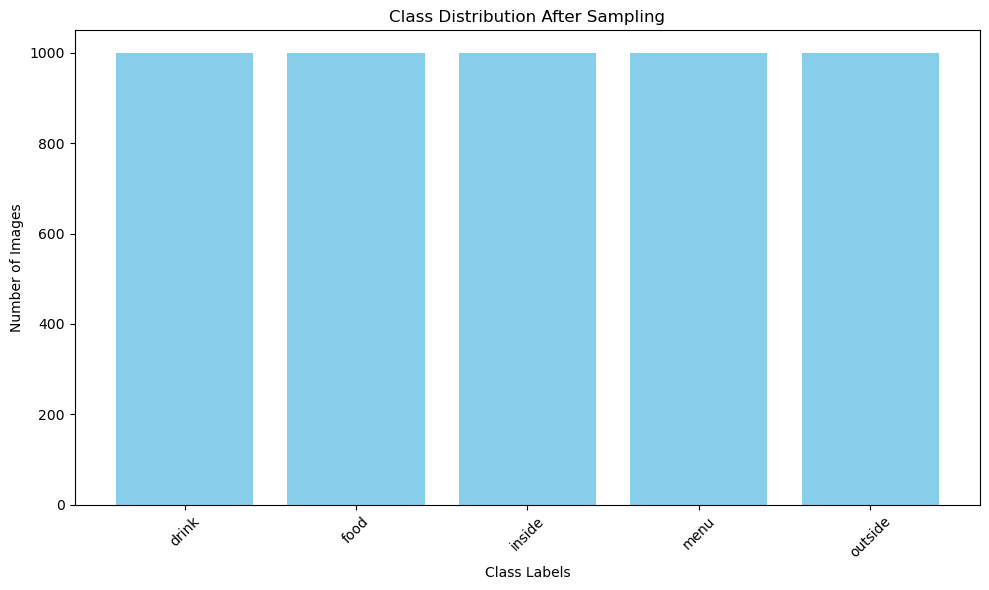

In [2]:
import matplotlib.pyplot as plt
from collections import Counter

# Count occurrences of each label
label_counts = Counter(labels)

# Plot the distribution
plt.figure(figsize=(10, 6))
plt.bar(label_counts.keys(), label_counts.values(), color='skyblue')
plt.xlabel("Class Labels")
plt.ylabel("Number of Images")
plt.title("Class Distribution After Sampling")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Label encoding 

In [3]:
from sklearn.preprocessing import LabelEncoder
import pickle

# Encode class labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

# Save for later decoding
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

In [4]:
from sklearn.model_selection import train_test_split
import numpy as np

sampled = []
sampled_labels = []
sampled_meta = []

for label, paths in class_to_paths.items():
    chosen = np.random.choice(paths, n_per_class, replace=False)
    sampled.extend(chosen)
    sampled_labels.extend([label] * len(chosen))
    sampled_meta.extend([[len(p)] for p in chosen])  

# Encode labels and convert metadata to numpy
encoded_sampled_labels = label_encoder.transform(sampled_labels)
sampled_meta = np.array(sampled_meta)

# Train-test split
train_paths, val_paths, y_train, y_val, X_meta_train, X_meta_val = train_test_split(
    sampled, encoded_sampled_labels, sampled_meta, test_size=0.2, stratify=encoded_sampled_labels, random_state=42
)

In [5]:
import numpy as np
import cv2
from tensorflow.keras.utils import Sequence

class MultiInputDataGenerator(Sequence):
    def __init__(self, image_paths, metadata, labels, batch_size=32, shuffle=True):
        self.image_paths = image_paths
        self.metadata = metadata
        self.labels = labels
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.image_paths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        batch_image_paths = [self.image_paths[i] for i in batch_indices]
        batch_metadata = self.metadata[batch_indices]
        batch_labels = self.labels[batch_indices]

        images = []
        for path in batch_image_paths:
            img = cv2.imread(path)
            if img is not None:
                img = cv2.resize(img, (224, 224))
                img = img.astype(np.float32) / 255.0
                images.append(img)
            else:
                # Add a dummy image if loading fails
                images.append(np.zeros((224, 224, 3), dtype=np.float32))

        return (np.array(images), batch_metadata), np.array(batch_labels)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


## Model Building 

In [6]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# === VGG base model ===
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in vgg_base.layers:
    layer.trainable = False

x = Flatten()(vgg_base.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

# === Metadata input branch ===
meta_input = Input(shape=(X_meta_train.shape[1],), name="meta_input")
m = Dense(32, activation='relu')(meta_input)

# === Combine both branches ===
combined = Concatenate()([x, m])
z = Dense(128, activation='relu')(combined)
z = Dropout(0.5)(z)
output = Dense(len(label_encoder.classes_), activation='softmax')(z)

model = Model(inputs=[vgg_base.input, meta_input], outputs=output)

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv1 (Conv2D)         │ (None, 224, 224, 64)      │           1,792 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_conv2 (Conv2D)         │ (None, 224, 224, 64)      │          36,928 │ block1_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1_pool (MaxPooling2D)    │ (None, 112, 112, 64)      │               0 │ block1_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_conv1 (Conv2D)         │ (None, 112, 112, 128)     │          73,856 │ block1_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_conv2 (Conv2D)         │ (None, 112, 112, 128)     │         147,584 │ block2_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block2_pool (MaxPooling2D)    │ (None, 56, 56, 128)       │               0 │ block2_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv1 (Conv2D)         │ (None, 56, 56, 256)       │         295,168 │ block2_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv2 (Conv2D)         │ (None, 56, 56, 256)       │         590,080 │ block3_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_conv3 (Conv2D)         │ (None, 56, 56, 256)       │         590,080 │ block3_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block3_pool (MaxPooling2D)    │ (None, 28, 28, 256)       │               0 │ block3_conv3[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv1 (Conv2D)         │ (None, 28, 28, 512)       │       1,180,160 │ block3_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv2 (Conv2D)         │ (None, 28, 28, 512)       │       2,359,808 │ block4_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_conv3 (Conv2D)         │ (None, 28, 28, 512)       │       2,359,808 │ block4_conv2[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block4_pool (MaxPooling2D)    │ (None, 14, 14, 512)       │               0 │ block4_conv3[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block5_conv1 (Conv2D)         │ (None, 14, 14, 512)       │       2,359,808 │ block4_pool[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block5_conv2 (Conv2D)         │ (None, 14, 14, 512)       │       2,359,808 │ block5_conv1[0][0]         │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 21,175,173 (80.78 MB)

 Trainable params: 6,460,485 (24.64 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Model Training 

In [7]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time

# Callbacks
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ReduceLROnPlateau(patience=2, factor=0.5)
]

# Generators
train_gen = MultiInputDataGenerator(train_paths, X_meta_train, y_train, batch_size=32)
val_gen = MultiInputDataGenerator(val_paths, X_meta_val, y_val, batch_size=32)

start_time = time.time()
# Train
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=callbacks
)
end_time = time.time()

Epoch 1/5


C:\Users\Taranjot\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


125/125 ━━━━━━━━━━━━━━━━━━━━ 395s 3s/step - accuracy: 0.2482 - loss: 2.9615 - val_accuracy: 0.6410 - val_loss: 0.9481 - learning_rate: 1.0000e-04
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 402s 3s/step - accuracy: 0.4563 - loss: 1.5537 - val_accuracy: 0.6970 - val_loss: 0.8305 - learning_rate: 1.0000e-04
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 400s 3s/step - accuracy: 0.5633 - loss: 1.1799 - val_accuracy: 0.7180 - val_loss: 0.7450 - learning_rate: 1.0000e-04
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 400s 3s/step - accuracy: 0.6352 - loss: 0.9967 - val_accuracy: 0.7300 - val_loss: 0.7142 - learning_rate: 1.0000e-04
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 389s 3s/step - accuracy: 0.6471 - loss: 0.9173 - val_accuracy: 0.7350 - val_loss: 0.7144 - learning_rate: 1.0000e-04


Model Saving 

In [8]:
model.save("vgg_metadata_model.keras")

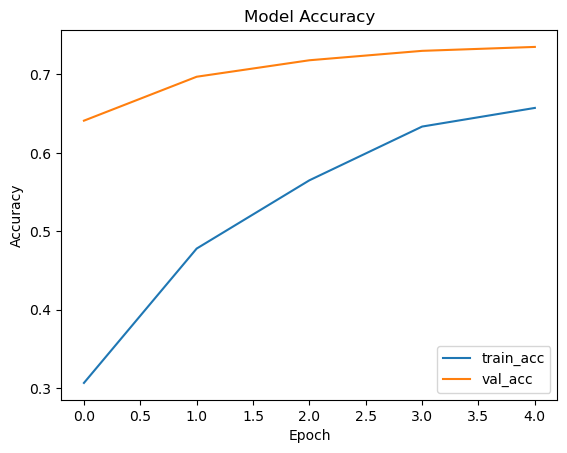

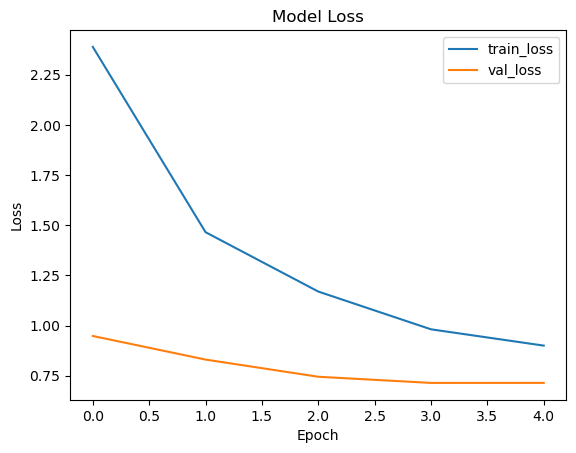

In [9]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Model Loading 

In [10]:
from tensorflow.keras.models import load_model

# Load the model
model = load_model(r"C:\Users\Taranjot\vgg_metadata_model.keras")

Predicting my randomly importing a image to check model accuracy 

In [11]:
import cv2

def predict_image_class(image_path, metadata_value):
    # Load image
    img = cv2.imread(image_path)
    if img is None:
        print("Error loading image.")
        return
    img = cv2.resize(img, (224, 224))
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=0)

    # Prepare metadata
    meta = np.array([[metadata_value]])

    # Predict
    pred = model.predict([img, meta], verbose=0)
    class_index = np.argmax(pred)
    class_name = label_encoder.inverse_transform([class_index])[0]
    confidence = np.max(pred)

    print(f"Predicted Class: {class_name} (Confidence: {confidence:.2f})")
    return class_name

In [12]:
predict_image_class(r"D:\Downloads\download.jpeg", metadata_value=80)

Predicted Class: food (Confidence: 0.97)


'food'

In [13]:
print(f"\nTraining time: {(end_time - start_time) / 60:.2f} minutes")


Training time: 33.11 minutes


In [16]:
import cv2
IMG_SIZE = 224

def load_images(paths):
    images = []
    for path in paths:
        img = cv2.imread(path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0  # Normalize
        images.append(img)
    return np.array(images)

X_val_image = load_images(val_paths)


In [17]:
from tensorflow.keras.utils import to_categorical

num_classes = len(label_encoder.classes_)
y_val_onehot = to_categorical(y_val, num_classes=num_classes)

Confusion Matrix plot 

32/32 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step


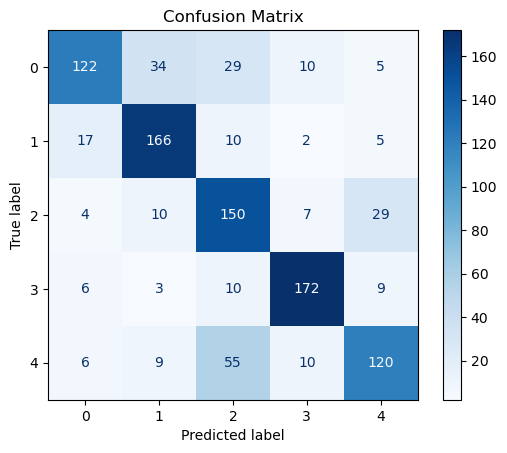

AUC Score: 0.9342


In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Predict
y_pred_probs = model.predict([X_val_image, X_meta_val])
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val_onehot, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# AUC Score
auc = roc_auc_score(y_val_onehot, y_pred_probs, multi_class='ovr')
print(f"AUC Score: {auc:.4f}")

ROC Curve Plot 

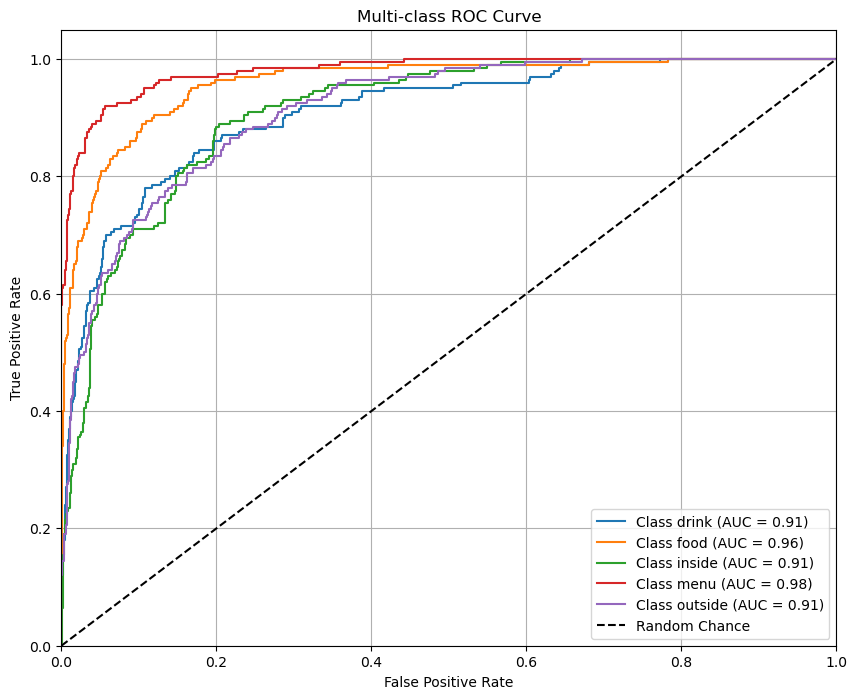

In [19]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
import numpy as np

# Get number of classes
n_classes = y_val_onehot.shape[1]
class_names = label_encoder.classes_

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_onehot[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()